# Phase 2 - Baseline Model Training

In [33]:
# Public Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import sys

# Custom Imports
src_dir = Path("../src")
sys.path.insert(0, str(src_dir))

from evaluate import *
from model import *
# from train import *

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Load Training and Test Data

In [34]:
# Define paths for data and models
data_dir = Path("../data/processed")

X_train_path = data_dir / "X_train.npy"
X_test_path = data_dir / "X_test.npy"
y_train_path = data_dir / "y_train.npy"
y_test_path = data_dir / "y_test.npy"

### commented out for the numpy files in

# train_data_path = data_dir / "train.csv"
# test_data_path = data_dir / "test.csv"

# # Load train and test data
# train_set = pd.read_csv(train_data_path)
# test_set = pd.read_csv(test_data_path)

# # Display test and train data
# print("Train Set:")
# display(train_set.head())
# print("Test Set:")
# display(test_set.head())

# Break down the train and test data into features and labels

### replaced this with numpy files from teams

# X_train = train_set.drop(columns=["label"])
# y_train = train_set["label"]
# X_test = test_set.drop(columns=["label"])
# y_test = test_set["label"]
###


# X_train = np.load(train_data_path)
# X_test = np.load(test_data_path)

X_train = np.load(X_train_path)
X_test = np.load(X_test_path)
y_train = np.load(y_train_path)
y_test = np.load(y_test_path)

# Display the contents of the train and test sets
# print("Train X Set:")
# display(X_train.head())
# print("Train y Set:")
# display(y_train.head())
# print("Test X Set:")
# display(X_test.head())
# print("Test y Set:")
# display(y_test.head())

# Display the shapes of the train and test sets

# print(f"Train Set Shape: {X_train.shape}, Labels Shape: {y_train.shape}")
# print(f"Test Set Shape: {X_test.shape}, Labels Shape: {y_test.shape}") 

print("Train X Set:")
display(X_train[:5])

print("Train y Set:")
display(y_train[:5])

print("Test X Set:")
display(X_test[:5])

print("Test y Set:")
display(y_test[:5])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train dtype:", X_train.dtype)
print("X_test dtype:", X_test.dtype)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("Training labels:")
print(np.unique(y_train, return_counts=True))
print("Testing labels:")
print(np.unique(y_test, return_counts=True))


Train X Set:


array([[-0.14556059, -0.02652612, -0.09209785,  0.        ,  0.        ,
         0.        , -0.05334714, -0.01006743,  0.5103131 , -0.00853813,
        -0.0166307 , -0.01152596, -0.01329284, -0.02856498, -0.02246034,
        -0.06486421,  0.        ,  0.        , -0.06325226, -0.10105179,
        -0.04223455, -0.06070573, -0.07336041, -0.23893514, -0.24189419,
         0.15489504, -0.15379085,  0.11912997,  1.1243894 ,  0.6013209 ,
         0.49691516, -0.29926488, -0.47052544, -0.50515455, -0.07702747,
        -0.07003175, -0.25253636, -0.25093088,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

Train y Set:


array([0, 0, 0, 0, 0])

Test X Set:


array([[-1.4556059e-01, -3.5006717e-02, -9.8555885e-02,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00, -5.3347137e-02, -1.0067435e-02,
        -1.9595814e+00, -8.5381325e-03, -1.6630700e-02, -1.1525964e-02,
        -1.3292844e-02, -2.8564978e-02, -2.2460341e-02, -6.4864211e-02,
         0.0000000e+00,  0.0000000e+00, -6.3252263e-02,  1.2484924e+01,
         3.0672678e-01,  3.5169701e+01,  3.6954346e+01, -2.3893514e-01,
        -2.4189419e-01, -9.9883099e+00,  2.7890164e-01, -5.0684112e-01,
         1.1243894e+00, -2.1583936e+00, -2.6389625e+00,  8.3879083e-02,
        -4.7052544e-01, -5.0515455e-01,  3.1640894e+01,  5.9351612e+01,
        -2.5253636e-01, -2.5093088e-01,  0.0000000e+00,  1.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.00000

Test y Set:


array([1, 1, 1, 0, 1])

X_train shape: (61482, 118)
X_test shape: (84104, 118)
X_train dtype: float32
X_test dtype: float32
y_train shape: (61482,)
y_test shape: (84104,)
Training labels:
(array([0]), array([61482]))
Testing labels:
(array([0, 1]), array([26350, 57754]))


## Model Architecture Setup (2.1)

In [15]:
# Develop functions here (Finsihed function go into the .py files in the src folder)

In [35]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Sequential

class Autoencoder(tf.keras.Model):

    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = Sequential([
            layers.Dense(32, activation="relu"),
            layers.Dense(latent_dim, activation="relu")
        ])

        self.decoder = Sequential([
            layers.Dense(32, activation="relu"),
            layers.Dense(input_dim, activation="linear")
        ])


    def call(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [36]:
# Test code cells here

# Initialize the model
...
model  = Autoencoder (input_dim = X_train.shape[1], latent_dim = 16)

## Train Tool Implementation (2.2)

In [37]:
# Develop functions here (Finsihed function go into the .py files in the src folder)

#from model import Autoencoder

###
#object_cols = X_train.select_dtypes(include=["object"]).columns

# print("Object columns:")
# print(object_cols)

# for col in object_cols:
#     print(f"\nColumn: {col}")
#     print(X_train[col].unique()[:10])

###




In [38]:
# Test code cells here

# Setup optimizer
# optimizer = keras.optimizers.Adam(learning_rate=0.001)

# Compile the model
model.compile(optimizer = 'adam', loss = 'mse')

# Add Checkpoint for model development
...

# Add Learning Rate Optimizer for model development
...

# Train Model
...
model.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=256
)

Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2160
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1165
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0827
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0644
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0535
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0452
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0368
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0313
Epoch 9/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0274
Epoch 10/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0251
Epoch 11/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0233
Epoch 12/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0215
Epoch 13/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0199
Epoch 14/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0189
Epoch 15/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

## Baseline Training & Anomaly Thresholding (2.3)

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize Global Variables for model development
THRESHOLD_PERCENTILE = 95

def calculate_reconstruction_error(model, data):
    """Calculate reconstruction error (MSE) for each sample."""
    reconstructed_data = model.predict(data, verbose=0)
    return np.mean(np.square(data - reconstructed_data), axis=1)

def generate_anomaly_metrics_and_threshold(model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE):
    """
    Generate anomaly threshold and evaluation metrics with visualization.
    
    Parameters:
    - model: Trained autoencoder model
    - X_train: Training data (for threshold calibration)
    - X_test: Test data (for evaluation)
    - y_test: Test labels
    - percentile: Percentile for threshold determination
    
    Returns:
    - threshold: Calculated anomaly threshold
    - y_pred: Predicted anomaly labels for test set
    """
    # Calculate reconstruction errors (single pass)
    train_errors = calculate_reconstruction_error(model, X_train)
    test_errors = calculate_reconstruction_error(model, X_test)
    
    # Determine threshold from training data
    threshold = np.percentile(train_errors, percentile)
    print(f"Train set Anomaly Threshold (Percentile {percentile}): {threshold:.4f}\n")
    
    # Determine threshold from test data (optional, for comparison)
    test_threshold = np.percentile(test_errors, percentile)
    print(f"Test Set Threshold (Percentile {percentile}): {test_threshold:.4f}\n")
    
    # Predict anomalies for test set
    y_pred = np.where(test_errors > threshold, 1, 0)
    
    # Visualization 1: Reconstruction Error Distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train_errors, bins=50, kde=True, label='Training', alpha=0.7)
    plt.axvline(threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({percentile}th %ile)')
    plt.title('Reconstruction Error Distribution (Training Data)')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Frequency')
    plt.legend()
    
    # Visualization 2: Test Set Anomaly Detection
    plt.subplot(1, 2, 2)
    colors = ['green' if pred == 0 else 'red' for pred in y_pred]
    plt.scatter(range(len(test_errors)), test_errors, c=colors, alpha=0.6, s=30)
    plt.axhline(threshold, color='r', linestyle='--', linewidth=2, label='Threshold')
    plt.title('Test Set: Reconstruction Error vs Sample Index')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.legend()
    
    # plt.tight_layout()
    plt.show()
    
    # Evaluation Metrics
    print("="*50)
    print("TEST SET EVALUATION METRICS")
    print("="*50)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return threshold, y_pred


Generating anomaly metrics and threshold
Train set Anomaly Threshold (Percentile 95): 0.0268

Test Set Threshold (Percentile 95): 1.9479



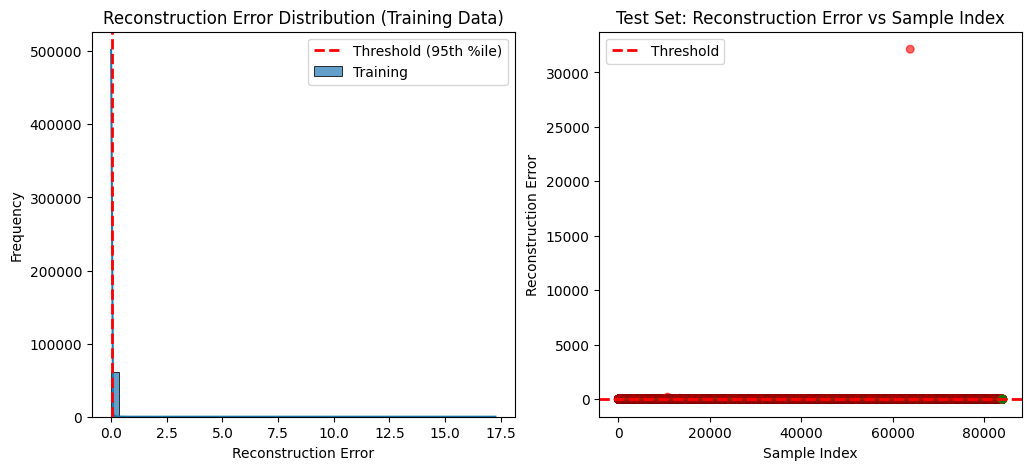

TEST SET EVALUATION METRICS
Accuracy: 0.9772

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     26350
           1       0.98      0.99      0.98     57754

    accuracy                           0.98     84104
   macro avg       0.98      0.97      0.97     84104
weighted avg       0.98      0.98      0.98     84104

Confusion Matrix:
[[25003  1347]
 [  574 57180]]


In [42]:
print("Generating anomaly metrics and threshold")
threshold, y_pred = generate_anomaly_metrics_and_threshold(model, X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE)

In [31]:
# Load the model (assuming the model is saved in the 'models' directory)
model_path = Path("../models/autoencoder_model.h5")
if model_path.exists():
    model = keras.models.load_model(model_path)
    print("Model loaded successfully.")
else:
    print("Model file not found. Please ensure the model is trained and saved in the 'models' directory.")
    
# Evaluate the model's anomaly detection performance on the test set
# _, _ = generate_anomaly_metrics_and_threshold(..., X_train, X_test, y_test, percentile=THRESHOLD_PERCENTILE)



Model file not found. Please ensure the model is trained and saved in the 'models' directory.
